In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets

wine  = datasets.load_wine()
df = pd.DataFrame(data = wine.data, columns=wine.feature_names)
df['target'] = wine.target

# check data fram head
print(df.head())

# chack column name
print(df.columns)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

target
1    71
0    59
2    48
Name: count, dtype: int64
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


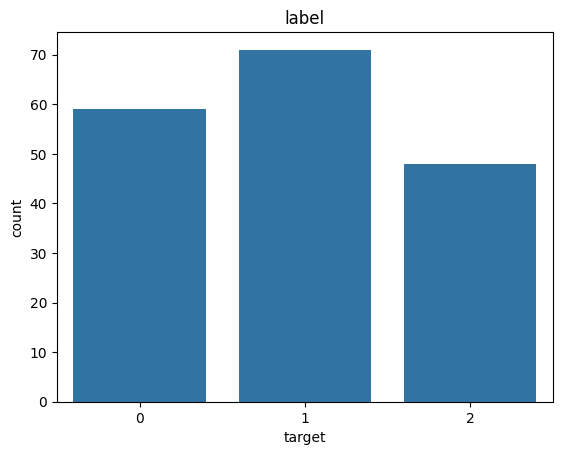

In [2]:
# check label count
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data = df, x='target')
plt.xlabel = ('Cancer or Not')
plt.ylabel = ('Count')
plt.title('label')

# check count
print(df['target'].value_counts())

# missing values check
print(df.isnull().sum())

In [3]:
# missing values delete
df = df.dropna()
print(df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [4]:
# Feature Selection ( Random Forest by Claude )
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)     # class init
rf.fit(df.drop('target', axis=1), df['target']) # target value delete

importances = pd.Series(rf.feature_importances_, index=df.drop('target', axis=1).columns)
importances.sort_values(ascending=False).head(10)   # 높은 순으로 sort

proline                         0.193999
flavanoids                      0.160954
color_intensity                 0.145267
alcohol                         0.110700
od280/od315_of_diluted_wines    0.109747
hue                             0.089690
malic_acid                      0.042186
total_phenols                   0.038520
magnesium                       0.035120
proanthocyanins                 0.026255
dtype: float64

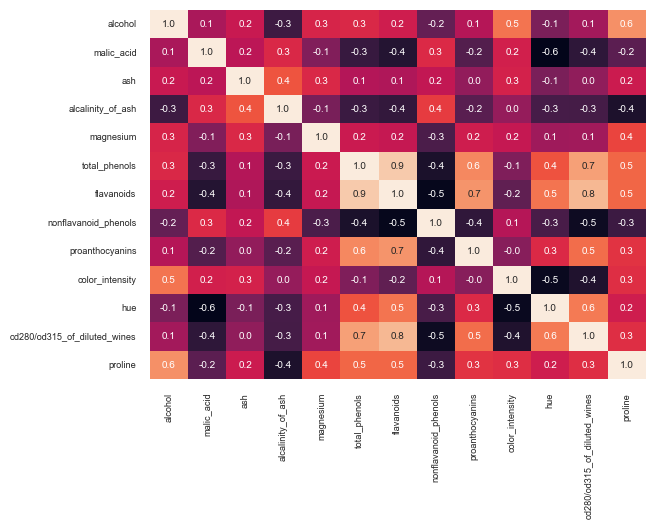

flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
Name: target, dtype: float64


In [5]:
# Feature Selection ( Correlation )
import seaborn as sns
import matplotlib.pyplot as plt

cf = df.drop('target', axis=1) # target value delete
#cf = df.copy()
cf_matrix = cf.corr()
plt.Figure(figsize=(15,15))
sns.set(font_scale=0.6)
#sns.heatmap(cf_matrix, annot = True, cbar = False)
sns.heatmap(cf_matrix, annot=True, cbar=False, fmt='.1f')
plt.show()

# sort target by claude 
corr_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print(corr_target.head(10))

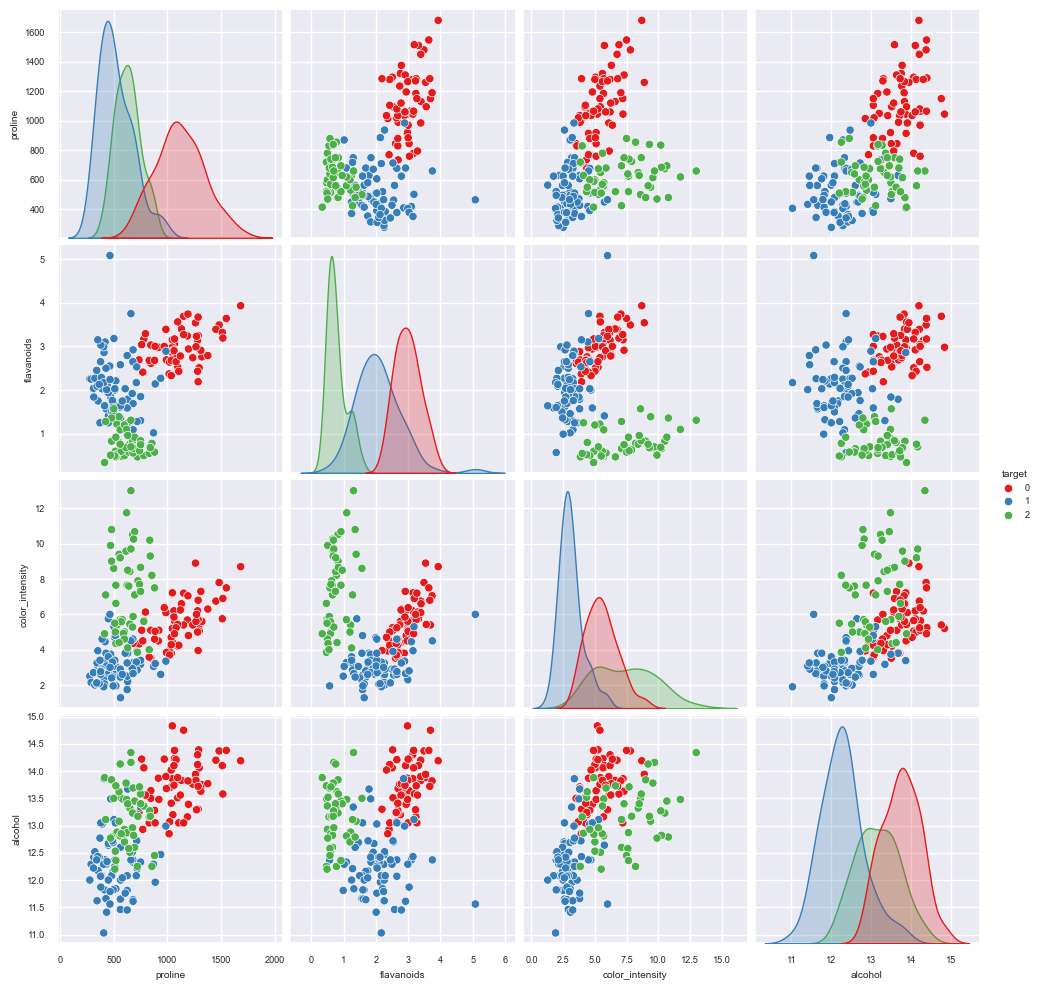

In [6]:
# check graph 
sns.pairplot(df, 
             vars=['proline','flavanoids', 'color_intensity', 'alcohol'], 
             hue='target', 
             palette='Set1',  # 구분이 잘 가는 색상 테마
             diag_kind='kde') # 대각선에는 분포 곡선 표시
plt.show()

# check to target and label data
# 1) missing data check and delete
# 2) Feature selection use to random forest (by claude)
# 3) check graph 
# so) classification 
# so) regression (y = target) -> good target data

In [8]:
# Marchin Learning
# classificatoin
c_df = df.copy()
c_y = c_df['target']
c_x = c_df.drop('target', axis=1)

# regression
r_df = df.copy()
r_y = r_df['flavanoids']
r_x = r_df.drop(['target','flavanoids'], axis=1)

# regression
# add standardscaler
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

rx = scaler_x.fit_transform(r_x)
ry = scaler_y.fit_transform(r_y.values.reshape(-1, 1)).flatten()

In [9]:
# classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test =  train_test_split(c_x, c_y, test_size=0.2, random_state=0)

c1,c2,c3 = LogisticRegression(random_state=0), DecisionTreeClassifier(random_state=0), RandomForestClassifier(random_state=0)
c1.fit(X_train, y_train); c2.fit(X_train, y_train); c3.fit(X_train,y_train)
c1_y, c2_y, c3_y = c1.predict(X_test), c2.predict(X_test), c3.predict(X_test)

print(f'Logistic Regression \n {classification_report(y_test, c1_y)}')
print(f'Decision Tree \n {classification_report(y_test, c2_y)}')
print(f'Random Forest \n {classification_report(y_test, c3_y)}')


Logistic Regression 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      0.88      0.90        16
           2       0.86      1.00      0.92         6

    accuracy                           0.92        36
   macro avg       0.91      0.93      0.92        36
weighted avg       0.92      0.92      0.92        36

Decision Tree 
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        16
           2       1.00      1.00      1.00         6

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36

Random Forest 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test =  train_test_split(rx, ry, test_size=0.2, random_state=0)

r1,r2,r3 = LinearRegression(), DecisionTreeRegressor(), RandomForestRegressor()
r1.fit(X_train, y_train); r2.fit(X_train, y_train); r3.fit(X_train,y_train)
r1_y, r2_y, r3_y = r1.predict(X_test), r2.predict(X_test), r3.predict(X_test)

print(f'Linear Regression \n {mean_squared_error(y_test, r1_y)}')
print(f'Decision Tree \n {mean_squared_error(y_test, r2_y)}')
print(f'Random Forest \n {mean_squared_error(y_test, r3_y)}')

Linear Regression 
 0.3197432954327605
Decision Tree 
 0.29795537719595855
Random Forest 
 0.2352859672852951


In [16]:
# Deep Learning
from sklearn.preprocessing import StandardScaler

# classification
scaler_c = StandardScaler()
d_c_x = scaler_c.fit_transform(c_x)
d_c_y = pd.get_dummies(c_y).values

# regression
scaler_x = StandardScaler()
scaler_y = StandardScaler()
d_r_x = scaler_x.fit_transform(r_x)
d_r_y = scaler_y.fit_transform(r_y.values.reshape(-1, 1)).flatten()

print(d_c_y)
print(d_c_x)


[[ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False

In [17]:
# check input shape
d_c_x.shape[1]

13

In [18]:
# classification
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

X_train,X_test, y_train,y_test = train_test_split(d_c_x,d_c_y,test_size=0.2,random_state=0) 

model = Sequential()

model.add(Dense(10, input_shape=(13,), activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(3,activation='softmax')) # output layer
#model.add(Dense(1,activation='sigmoid')) # output layer

model.compile(Adam(learning_rate=0.04), 'categorical_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.18 KB)

 Trainable params: 303 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model_history = model.fit(
    x=X_train, y=y_train,                       # data fraim input
    epochs=30,                                  # fitting counter
    batch_size=32,                              # group count 
    validation_data= (X_test, y_test))          # fitting monitoring

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

#y_pred_class = (y_pred > 0.5).astype(int).flatten()
#y_test_class = y_test

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5493 - loss: 0.9243 - val_accuracy: 0.6667 - val_loss: 0.6758
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8028 - loss: 0.5317 - val_accuracy: 0.8056 - val_loss: 0.5349
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9366 - loss: 0.3602 - val_accuracy: 0.9167 - val_loss: 0.3289
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9789 - loss: 0.2639 - val_accuracy: 1.0000 - val_loss: 0.2398
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9930 - loss: 0.1907 - val_accuracy: 0.9444 - val_loss: 0.1905
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9930 - loss: 0.1342 - val_accuracy: 0.9444 - val_loss: 0.1650
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9930 - loss: 0.0997 - val_accuracy: 0.9722 - val_loss: 0.1197
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0700 - val_accuracy: 1.0000 - val_loss: 0.0933


In [20]:
# classification
from sklearn.metrics import classification_report,confusion_matrix

print(f'Deep Learning \n {classification_report(y_test_class, y_pred_class)}')
print(f'Deep Learning \n {confusion_matrix(y_test_class, y_pred_class)}')

Deep Learning 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.86      1.00      0.92         6

    accuracy                           0.97        36
   macro avg       0.95      0.98      0.96        36
weighted avg       0.98      0.97      0.97        36

Deep Learning 
 [[14  0  0]
 [ 0 15  1]
 [ 0  0  6]]


In [21]:
# check input shape
d_r_x.shape[1]

12

In [23]:
# regression
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

X_train,X_test, y_train,y_test = train_test_split(d_r_x,d_r_y,test_size=0.2,random_state=0) 

model = Sequential()

model.add(Dense(10, input_shape=(12,), activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1)) # output layer

# function information by claude
# rmsprop → 각 파라미터마다 학습률을 다르게 적용
# Adam → rmsprop + momentum 결합, 더 안정적으로 수렴
#model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mse'])


model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279 (1.09 KB)

 Trainable params: 279 (1.09 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_history = model.fit(
    x=X_train, y=y_train,                       # data fraim input
    epochs=30,                                  # fitting counter
    batch_size=32,                              # group count 
    validation_data= (X_test, y_test))    # fitting monitoring

y_pred = model.predict(X_test)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.9944 - mse: 0.9944 - val_loss: 1.1150 - val_mse: 1.1150
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9424 - mse: 0.9424 - val_loss: 1.0655 - val_mse: 1.0655
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8972 - mse: 0.8972 - val_loss: 1.0189 - val_mse: 1.0189
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8540 - mse: 0.8540 - val_loss: 0.9804 - val_mse: 0.9804
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8105 - mse: 0.8105 - val_loss: 0.9456 - val_mse: 0.9456
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7637 - mse: 0.7637 - val_loss: 0.9073 - val_mse: 0.9073
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7204 - mse: 0.7204 - val_loss: 0.8724 - val_mse: 0.8724
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6743 - mse: 0.6743 - val_loss: 0.8335 - val_mse: 0.8335
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6282 - mse: 0.6282 - 

In [25]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4686 - mse: 0.4686


[0.4686077833175659, 0.4686077833175659]

In [26]:
# add regression check by claude 
from sklearn.metrics import mean_squared_error, r2_score

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'Deep Learning MSE:  {mse}')
print(f'Deep Learning RMSE: {rmse}')
print(f'Deep Learning R²:   {r2}')

Deep Learning MSE:  0.4686077901469025
Deep Learning RMSE: 0.6845493336107359
Deep Learning R²:   0.5572066056406768
